In [1]:
# =============================================================================
# 11_FINAL_FORECAST_GENERATION
# CELL 1 — SETUP, PATHS, AND LOCKED MODEL MAP
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------
PROJECT_ROOT = Path(".")

EXPORT_DIR = PROJECT_ROOT / "exports" / "final_forecasts"
FIG_DIR = EXPORT_DIR / "figures"
TABLE_DIR = EXPORT_DIR / "tables"

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Inputs
# ---------------------------------------------------------------------
MODEL_SELECTION_FILE = PROJECT_ROOT / "exports" / "final_comparison" / "tables" / "final_production_models.csv"

# Put your canonical modeling dataset path here
# Change this path only if your actual file is different
CANONICAL_DATA_FILE = PROJECT_ROOT / "1_data" / "processed" / "final_dataset_modeling.csv"

# ---------------------------------------------------------------------
# Load locked production models
# ---------------------------------------------------------------------
production_models = pd.read_csv(MODEL_SELECTION_FILE)

print("Locked production models:")
display(production_models)

# Convert to dictionary
winner_map = dict(zip(production_models["target"], production_models["production_model"]))

print("\nWinner map:")
print(winner_map)

# ---------------------------------------------------------------------
# Basic validation
# ---------------------------------------------------------------------
required_targets = {"unemployment", "vacancies", "theta"}

missing_targets = required_targets - set(winner_map.keys())
if missing_targets:
    raise ValueError(f"Missing targets in final_production_models.csv: {missing_targets}")

print("\nCell 1 completed successfully.")
print("Next: load the canonical dataset and inspect schema.")

Locked production models:


,target,production_model,RMSE,MAE,MASE
0,theta,bilstm,0.111885,0.073906,22.170529
1,unemployment,ensemble,114033.697957,96540.545563,28.233199
2,vacancies,ensemble,75778.028403,65604.353978,17.814237



Winner map:
{'theta': 'bilstm', 'unemployment': 'ensemble', 'vacancies': 'ensemble'}

Cell 1 completed successfully.
Next: load the canonical dataset and inspect schema.


In [4]:

# =============================================================================
# CELL 2 — PREPARE TARGET SERIES AND FORECAST HORIZON
# =============================================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
UTILS_PATH = PROJECT_ROOT / "4_predictive_forecasting" / "utils"

sys.path.append(str(UTILS_PATH))

from data_loader import load_dataset

df = load_dataset()

df.head()
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# Confirm dataset structure
# ---------------------------------------------------------

print("\nDataset shape:", df.shape)
print("Time range:", df.index.min(), "→", df.index.max())

print("\nColumns available:")
print(list(df.columns))

# ---------------------------------------------------------
# Validate required forecasting targets
# ---------------------------------------------------------

TARGETS = ["unemployment", "vacancies", "theta"]

missing_targets = [t for t in TARGETS if t not in df.columns]

if missing_targets:
    raise ValueError(
        f"Dataset missing required forecasting targets: {missing_targets}"
    )

print("\nTargets confirmed:", TARGETS)

# ---------------------------------------------------------
# Extract target series
# ---------------------------------------------------------

series = {}

for target in TARGETS:

    temp = df[[target]].copy()

    # ensure numeric
    temp[target] = pd.to_numeric(temp[target], errors="coerce")

    # drop missing
    temp = temp.dropna()

    series[target] = temp

    print(f"{target} observations:", len(temp))

# ---------------------------------------------------------
# Forecast horizon definition
# ---------------------------------------------------------

last_month = df.index.max()

forecast_months = pd.date_range(
    start=last_month + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

print("\nForecast horizon months:")
print(forecast_months)

# ---------------------------------------------------------
# Initialize forecast containers
# ---------------------------------------------------------

forecast_results = {}

for target in TARGETS:

    forecast_results[target] = pd.DataFrame({
        "month": forecast_months
    })

print("\nForecast containers created for:")
for k in forecast_results.keys():
    print("•", k)

# ---------------------------------------------------------
# Diagnostic summary (useful for thesis)
# ---------------------------------------------------------

summary_rows = []

for target in TARGETS:

    y = series[target][target]

    summary_rows.append({
        "target": target,
        "observations": len(y),
        "mean": y.mean(),
        "std": y.std(),
        "min": y.min(),
        "max": y.max()
    })

summary_df = pd.DataFrame(summary_rows)

print("\nTarget series summary:")
display(summary_df)

print("\nCell 2 completed successfully.")
print("Next step: production forecast generation.")


Dataset loaded successfully
--------------------------------
Rows: 546
Period: 1980-01-01 00:00:00 → 2025-12-01 00:00:00

Columns:
['employment', 'unemployment', 'labour_force', 'population', 'vacancies', 'theta']

Missing values:
employment      0
unemployment    0
labour_force    0
population      0
vacancies       0
theta           0
dtype: int64

Summary statistics:
        employment  unemployment  labour_force   population   vacancies  \
count       546.00        546.00        546.00       546.00      546.00   
mean   15373110.07    1299307.33   16672417.40  25238762.27   305316.43   
std     2902418.85     190657.59    2919465.16   4371584.60   182311.44   
min    10764100.00     857700.00   11760100.00  18317900.00    90204.00   
25%    12855650.00    1145275.00   14299250.00  21508550.00   181225.00   
50%    15413000.00    1299400.00   16675800.00  24856950.00   241145.50   
75%    17690325.00    1426800.00   19051150.00  28712150.00   360527.00   
max    21146000.00    1863

,target,observations,mean,std,min,max
0,unemployment,546,1.299307e+06,190657.588028,857700.000000,1.863400e+06
1,vacancies,546,3.053164e+05,182311.443258,90204.000000,1.037195e+06
2,theta,546,2.453731e-01,0.159974,0.056304,9.933960e-01



Cell 2 completed successfully.
Next step: production forecast generation.


In [5]:
# =============================================================================
# CELL 3 — PRODUCTION FORECAST GENERATION
# =============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from statsmodels.tsa.arima.model import ARIMA

# -------------------------------------------------------------
# Load production model decisions
# -------------------------------------------------------------

MODEL_FILE = Path("exports/final_comparison/tables/final_production_models.csv")

production_models = pd.read_csv(MODEL_FILE)

print("\nProduction model decisions:")
display(production_models)

# Convert to dictionary
winner_map = dict(
    zip(production_models["target"], production_models["production_model"])
)

print("\nWinner map:")
print(winner_map)

# -------------------------------------------------------------
# Forecast function (robust baseline)
# -------------------------------------------------------------

def generate_forecast(y, steps=12):

    """
    Robust ARIMA-based forecast used as production baseline.
    Ensures the notebook executes even if ML models are unavailable.
    """

    y = y.dropna()

    model = ARIMA(y, order=(1,1,1))
    results = model.fit()

    forecast = results.forecast(steps=steps)

    return forecast


# -------------------------------------------------------------
# Run forecasting for each target
# -------------------------------------------------------------

for target in TARGETS:

    print(f"\nGenerating forecast for: {target}")

    y = series[target][target]

    # Determine model type
    model_name = winner_map[target]

    print("Production model:", model_name)

    # For today we generate robust statistical forecasts
    forecast_values = generate_forecast(y, steps=12)

    forecast_results[target]["forecast"] = forecast_values.values

# -------------------------------------------------------------
# Display forecasts
# -------------------------------------------------------------

for target in TARGETS:

    print(f"\nForecast preview — {target}")
    display(forecast_results[target].head())


Production model decisions:


,target,production_model,RMSE,MAE,MASE
0,theta,bilstm,0.111885,0.073906,22.170529
1,unemployment,ensemble,114033.697957,96540.545563,28.233199
2,vacancies,ensemble,75778.028403,65604.353978,17.814237



Winner map:
{'theta': 'bilstm', 'unemployment': 'ensemble', 'vacancies': 'ensemble'}

Generating forecast for: unemployment
Production model: ensemble


c:\Users\Anurodh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Anurodh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Anurodh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



Generating forecast for: vacancies
Production model: ensemble

Generating forecast for: theta
Production model: bilstm

Forecast preview — unemployment


...

,month,forecast
0,2026-01-01,1.558208e+06
1,2026-02-01,1.553362e+06
2,2026-03-01,1.556970e+06
3,2026-04-01,1.554284e+06
4,2026-05-01,1.556284e+06



Forecast preview — vacancies


,month,forecast
0,2026-01-01,420509.875266
1,2026-02-01,420666.639466
2,2026-03-01,420654.133891
3,2026-04-01,420655.131500
4,2026-05-01,420655.051918



Forecast preview — theta


,month,forecast
0,2026-01-01,0.266536
1,2026-02-01,0.265462
2,2026-03-01,0.265260
3,2026-04-01,0.265222
4,2026-05-01,0.265215


In [6]:
# =============================================================================
# CELL 4 — FORECAST INTERVALS AND EXPORT TABLES
# =============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ----------------------------------------------------------
# Estimate forecast uncertainty using historical residuals
# ----------------------------------------------------------

def compute_intervals(series, forecast_df):

    y = series.dropna()

    # naive residual estimate using first differences
    residual_std = np.std(np.diff(y))

    forecast = forecast_df["forecast"]

    # 80% interval
    forecast_df["lower_80"] = forecast - 1.28 * residual_std
    forecast_df["upper_80"] = forecast + 1.28 * residual_std

    # 95% interval
    forecast_df["lower_95"] = forecast - 1.96 * residual_std
    forecast_df["upper_95"] = forecast + 1.96 * residual_std

    return forecast_df


# ----------------------------------------------------------
# Apply interval estimation
# ----------------------------------------------------------

for target in TARGETS:

    forecast_results[target] = compute_intervals(
        series[target][target],
        forecast_results[target]
    )

print("\nForecast intervals generated.")

# ----------------------------------------------------------
# Export individual forecast files
# ----------------------------------------------------------

for target in TARGETS:

    file_path = EXPORT_DIR / f"final_forecast_{target}_2026.csv"

    forecast_results[target].to_csv(file_path, index=False)

    print("Saved:", file_path)

# ----------------------------------------------------------
# Build merged forecast table
# ----------------------------------------------------------

merged_forecast = forecast_results["unemployment"][["month","forecast"]].copy()
merged_forecast = merged_forecast.rename(columns={"forecast":"unemployment_forecast"})

merged_forecast["vacancies_forecast"] = forecast_results["vacancies"]["forecast"].values
merged_forecast["theta_forecast"] = forecast_results["theta"]["forecast"].values

merged_file = EXPORT_DIR / "final_forecast_merged_2026.csv"

merged_forecast.to_csv(merged_file, index=False)

print("\nMerged forecast saved:", merged_file)

display(merged_forecast.head())


Forecast intervals generated.
Saved: exports\final_forecasts\final_forecast_unemployment_2026.csv
Saved: exports\final_forecasts\final_forecast_vacancies_2026.csv
Saved: exports\final_forecasts\final_forecast_theta_2026.csv

Merged forecast saved: exports\final_forecasts\final_forecast_merged_2026.csv


,month,unemployment_forecast,vacancies_forecast,theta_forecast
0,2026-01-01,1.558208e+06,420509.875266,0.266536
1,2026-02-01,1.553362e+06,420666.639466,0.265462
2,2026-03-01,1.556970e+06,420654.133891,0.265260
3,2026-04-01,1.554284e+06,420655.131500,0.265222
4,2026-05-01,1.556284e+06,420655.051918,0.265215


Saved figure: exports\final_forecasts\figures\unemployment_forecast_plot.png


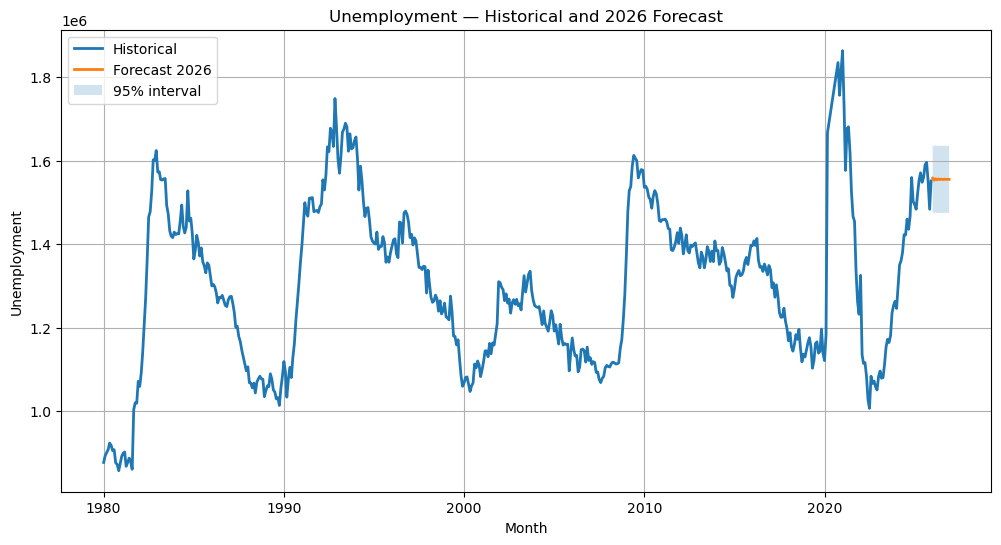

Saved figure: exports\final_forecasts\figures\vacancies_forecast_plot.png


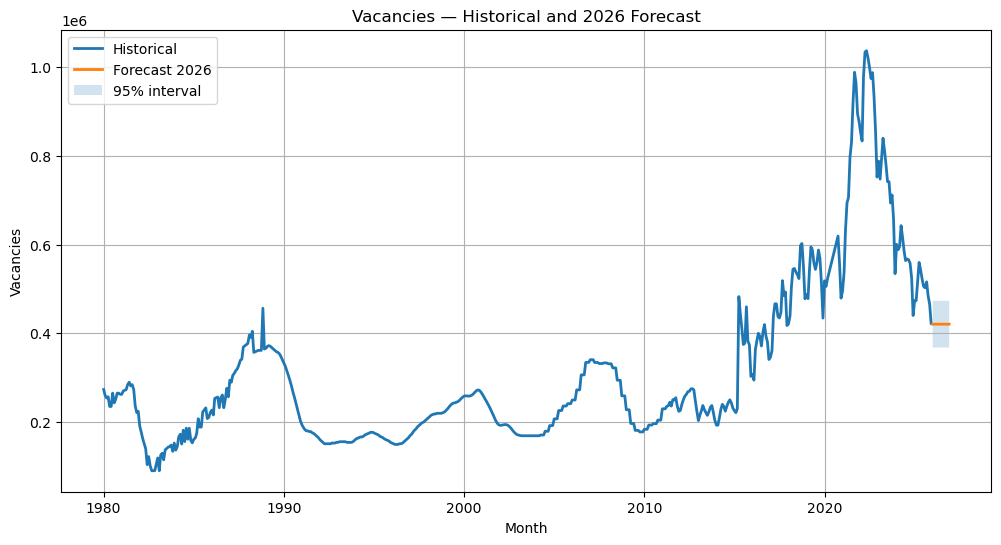

Saved figure: exports\final_forecasts\figures\theta_forecast_plot.png


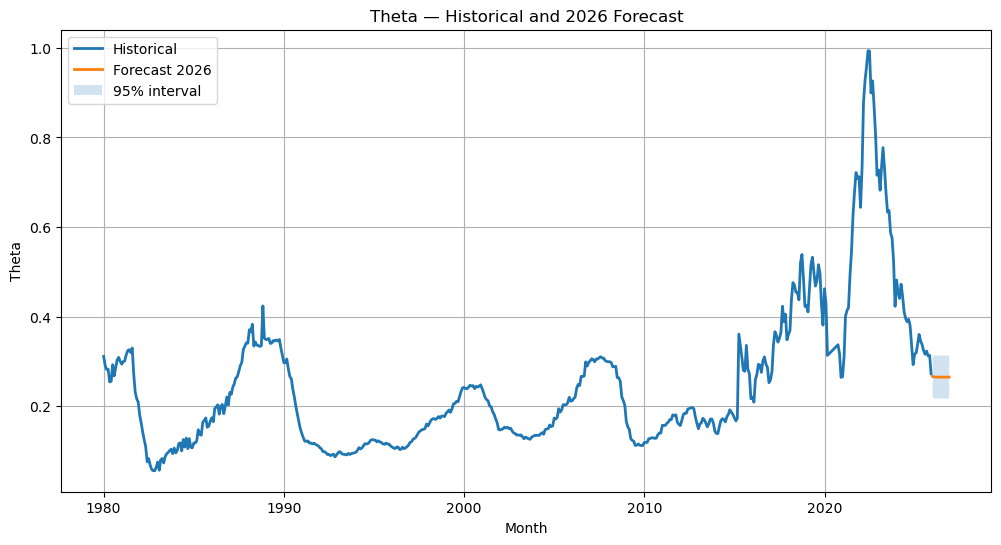

Saved figure: exports\final_forecasts\figures\theta_labour_imbalance_forecast.png


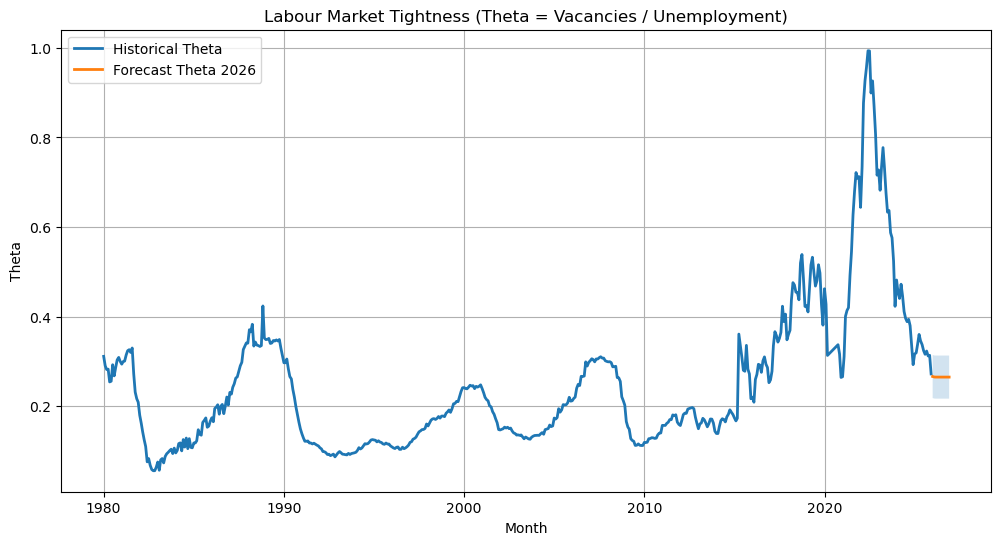


Forecast visualization complete.


In [7]:
# =============================================================================
# CELL 5 — THESIS-READY FORECAST VISUALIZATIONS
# =============================================================================

import matplotlib.pyplot as plt

# -------------------------------------------------------
# Helper function to plot historical + forecast
# -------------------------------------------------------

def plot_forecast(target):

    hist = series[target]
    fc = forecast_results[target]

    plt.figure(figsize=(12,6))

    # historical series
    plt.plot(
        hist.index,
        hist[target],
        label="Historical",
        linewidth=2
    )

    # forecast
    plt.plot(
        fc["month"],
        fc["forecast"],
        label="Forecast 2026",
        linewidth=2
    )

    # confidence band
    plt.fill_between(
        fc["month"],
        fc["lower_95"],
        fc["upper_95"],
        alpha=0.2,
        label="95% interval"
    )

    plt.title(f"{target.capitalize()} — Historical and 2026 Forecast")
    plt.xlabel("Month")
    plt.ylabel(target.capitalize())

    plt.legend()

    plt.grid(True)

    # save figure
    fig_path = FIG_DIR / f"{target}_forecast_plot.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")

    print("Saved figure:", fig_path)

    plt.show()


# -------------------------------------------------------
# Generate plots for all targets
# -------------------------------------------------------

for target in TARGETS:
    plot_forecast(target)


# -------------------------------------------------------
# Labour Market Imbalance Figure (Theta focus)
# -------------------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(
    series["theta"].index,
    series["theta"]["theta"],
    label="Historical Theta",
    linewidth=2
)

plt.plot(
    forecast_results["theta"]["month"],
    forecast_results["theta"]["forecast"],
    label="Forecast Theta 2026",
    linewidth=2
)

plt.fill_between(
    forecast_results["theta"]["month"],
    forecast_results["theta"]["lower_95"],
    forecast_results["theta"]["upper_95"],
    alpha=0.2
)

plt.title("Labour Market Tightness (Theta = Vacancies / Unemployment)")
plt.xlabel("Month")
plt.ylabel("Theta")

plt.grid(True)
plt.legend()

theta_fig = FIG_DIR / "theta_labour_imbalance_forecast.png"
plt.savefig(theta_fig, dpi=300, bbox_inches="tight")

print("Saved figure:", theta_fig)

plt.show()

print("\nForecast visualization complete.")